# Regional Crime Pattern Analysis

## Data Understanding

The USArrests dataset contains crime statistics for different US states. The goal is to identify natural groups of states with similar crime patterns using clustering techniques.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

# then your other imports
import sklearn
from sklearn.cluster import KMeans

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("USArrests.csv")

df.head()

,rownames,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [3]:
df.shape

(50, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  50 non-null     object 
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB


In [5]:
df.describe()

,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


In [6]:
df.isnull().sum()

rownames    0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

## Data Preparation

The crime variables have different scales. Standardization is required because clustering algorithms use distance calculations to determine similarity between observations.

In [7]:
X = df.drop("rownames", axis=1)

In [8]:
X.head()

,Murder,Assault,UrbanPop,Rape
0,13.2,236,58,21.2
1,10.0,263,48,44.5
2,8.1,294,80,31.0
3,8.8,190,50,19.5
4,9.0,276,91,40.6


In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 1.25517927,  0.79078716, -0.52619514, -0.00345116],
       [ 0.51301858,  1.11805959, -1.22406668,  2.50942392],
       [ 0.07236067,  1.49381682,  1.00912225,  1.05346626],
       [ 0.23470832,  0.23321191, -1.08449238, -0.18679398],
       [ 0.28109336,  1.2756352 ,  1.77678094,  2.08881393]])

## Dimensionality Reduction Using PCA

PCA was applied to reduce the number of dimensions while preserving the main patterns in the crime data. The dataset was reduced to two principal components to allow visualization of the clusters.

The first two principal components explained approximately **86.7% of the total variance**, meaning that most of the information from the original features was retained while reducing the complexity of the dataset.

In [10]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_pca[:5]

array([[ 0.98556588,  1.13339238],
       [ 1.95013775,  1.07321326],
       [ 1.76316354, -0.74595678],
       [-0.14142029,  1.11979678],
       [ 2.52398013, -1.54293399]])

In [11]:
pca.explained_variance_ratio_

array([0.62006039, 0.24744129])

In [12]:
sum(pca.explained_variance_ratio_)

0.8675016829223339

## K-Means Clustering

K-Means clustering was applied to identify groups of states with similar crime patterns. The elbow method was used to determine the appropriate number of clusters.

In [13]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_pca)
    
    inertia.append(kmeans.inertia_)

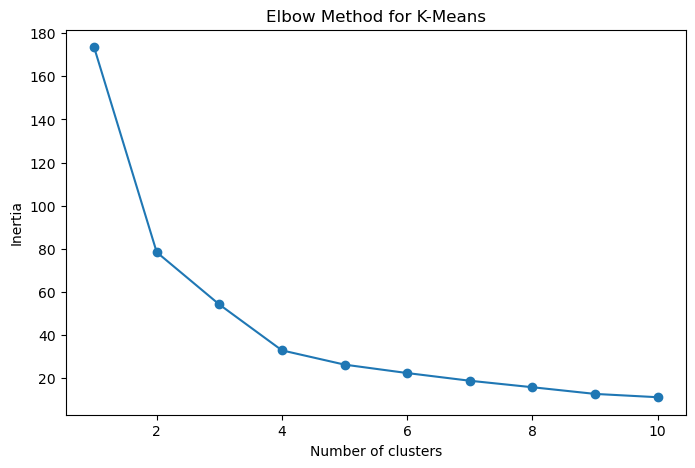

In [14]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker="o")

plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")

plt.show()

## Selecting the Number of K-Means Clusters

The elbow method was used to determine the optimal number of clusters. The largest reduction in inertia occurred before four clusters, after which improvements became smaller. Therefore, four clusters were selected for the K-Means model.

In [15]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_pca)

kmeans_labels[:10]

array([2, 2, 0, 2, 0, 0, 3, 3, 0, 2])

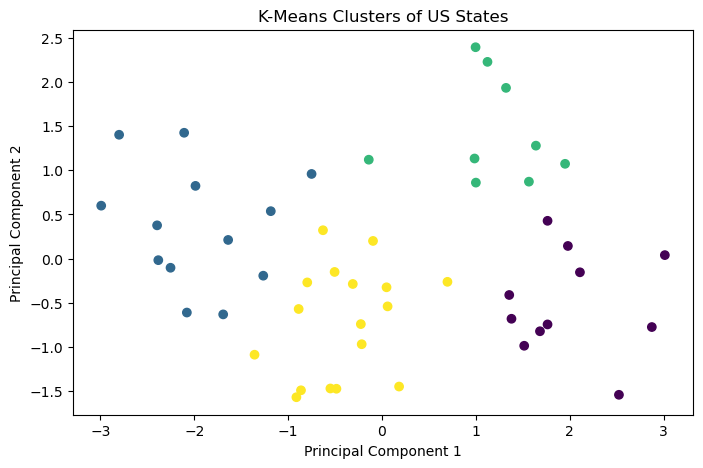

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters of US States")

plt.show()

## Evaluating K-Means Clustering

The silhouette score was used to evaluate the quality of the clusters. It measures how similar each state is to its assigned cluster compared with other clusters. Higher values indicate better separated and more distinct clusters.

In [17]:
from sklearn.metrics import silhouette_score

silhouette_kmeans = silhouette_score(
    X_pca,
    kmeans_labels
)

silhouette_kmeans

0.44383507838069947

The four K-Means clusters show a moderate separation. States within the same cluster are generally more similar to each other than states in different clusters, although some overlap exists.

## Gaussian Mixture Model (GMM) Clustering

A Gaussian Mixture Model was applied to perform probabilistic clustering. Unlike K-Means, which assigns each observation to a single cluster, GMM estimates the probability that each state belongs to different clusters.

In [18]:
bic_scores = []

for k in range(1, 11):
    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )
    
    gmm.fit(X_pca)
    
    bic_scores.append(gmm.bic(X_pca))

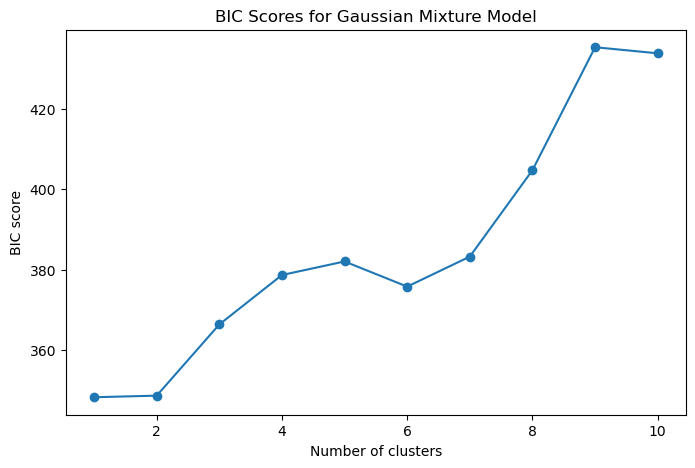

In [19]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    bic_scores,
    marker="o"
)

plt.xlabel("Number of clusters")
plt.ylabel("BIC score")
plt.title("BIC Scores for Gaussian Mixture Model")

plt.show()

## Selecting the Number of GMM Clusters

The Bayesian Information Criterion (BIC) was used to select the optimal number of Gaussian Mixture Model clusters. The lowest BIC value was observed with two clusters, suggesting that a two-cluster GMM provides the best balance between model fit and complexity.

In [20]:
gmm = GaussianMixture(
    n_components=2,
    random_state=42
)

gmm_labels = gmm.fit_predict(X_pca)

gmm_labels[:10]

array([1, 1, 1, 0, 1, 1, 0, 0, 1, 1], dtype=int64)

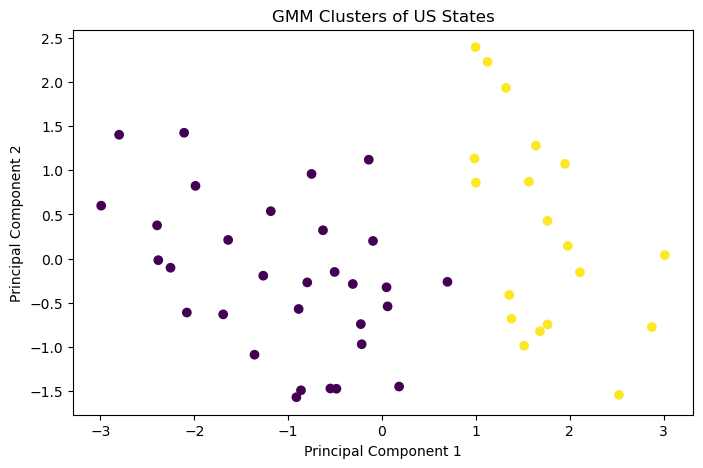

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=gmm_labels
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("GMM Clusters of US States")

plt.show()

## Comparing K-Means and Gaussian Mixture Model

Both K-Means and GMM were used to identify patterns in US crime statistics. K-Means produced four distinct clusters based on distance from cluster centers, while GMM identified two groups based on probability distributions.

K-Means provides simple hard cluster assignments, where each state belongs to one cluster. GMM provides a more flexible approach by estimating the probability of belonging to different clusters.

The results show that crime patterns can be grouped into broader regional profiles, although the exact grouping depends on the clustering method used.

In [22]:
comparison = pd.DataFrame({
    "Method": ["K-Means", "GMM"],
    "Number of clusters": [4, 2],
    "Evaluation": [
        round(silhouette_kmeans, 3),
        "Selected using lowest BIC"
    ]
})

comparison

,Method,Number of clusters,Evaluation
0,K-Means,4,0.444
1,GMM,2,Selected using lowest BIC


## Cluster Membership Summary

The cluster assignments below show how states were grouped based on similar crime patterns. This allows stakeholders to identify regions with comparable crime profiles for further analysis.

In [23]:
cluster_summary = pd.DataFrame({
    "State": df["rownames"],
    "KMeans Cluster": kmeans_labels,
    "GMM Cluster": gmm_labels
})

cluster_summary.head()

,State,KMeans Cluster,GMM Cluster
0,Alabama,2,1
1,Alaska,2,1
2,Arizona,0,1
3,Arkansas,2,0
4,California,0,1


## Conclusion

The USArrests dataset was successfully analyzed using clustering techniques. The data was standardized and reduced using PCA, retaining 86.75% of the original information.

K-Means identified four groups of states based on similarity in crime measurements, while GMM identified two broader probabilistic groups. These clusters can help policy researchers explore differences in crime patterns and identify regions requiring further investigation.